# Contour Integration & Residues: Deriving Kramers-Kronig

`dgs/branch_cuts.py` covers multi-valued functions (log, sqrt) with no
isolated singularity to circle. This notebook covers the OTHER kind of
complex-analysis singularity -- isolated poles -- and the residue theorem
that handles them, then uses it for something concrete: `dgs/causality.py`
*states* that causality forces a susceptibility's real and imaginary parts
to be Hilbert-transform (Kramers-Kronig) pairs, and verifies it
numerically with an FFT. This notebook *derives* that fact instead, from
one contour-integration argument, and cross-checks the result against
`dgs.causality`'s independent FFT-based method on the same susceptibility.
Engine: `dgs/contour_integration_residues.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

from dgs import contour_integration_residues as cir
from dgs import causality

sp.init_printing()
print('Setup complete.')


Setup complete.


## 1. The Residue Theorem, and Its Favorite Trap

$\oint f(z)\,dz = 2\pi i\sum(\text{enclosed residues})$ -- but "enclosed"
is load-bearing. $f(z)=1/(z^2+1)$ has poles at $+i$ and $-i$, both exactly
distance 1 from the origin -- so an origin-centered circle ALWAYS encloses
either both or neither, never just one. A small circle centered AT $+i$
is needed to isolate that pole alone.


In [2]:
z = sp.symbols('z')
f_sym = 1 / (z**2 + 1)

# a small circle centered at +i encloses ONLY that pole
single = cir.verify_residue_theorem(lambda zz: 1/(zz**2+1), f_sym, z, [sp.I], center=1j, radius=0.3)
print('contour centered at +i, radius 0.3 (encloses only +i):')
print(f"  numeric = {single['numeric_contour_integral']:.6f}, "
      f"residue theorem = {single['residue_theorem_prediction']:.6f}, diff = {single['abs_diff']:.2e}")

# an origin-centered circle of radius 5 encloses BOTH poles -- residues
# cancel (-i/2 and +i/2), giving a DIFFERENT, still-correct answer
both = cir.verify_residue_theorem(lambda zz: 1/(zz**2+1), f_sym, z, [sp.I, -sp.I], center=0.0, radius=5.0)
print('\ncontrast -- origin-centered radius 5.0 (encloses BOTH poles):')
print(f"  numeric = {both['numeric_contour_integral']:.6f}, "
      f"residue theorem = {both['residue_theorem_prediction']:.6f}, diff = {both['abs_diff']:.2e}")


contour centered at +i, radius 0.3 (encloses only +i):
  numeric = 3.141593-0.000000j, residue theorem = 3.141593+0.000000j, diff = 4.16e-17

contrast -- origin-centered radius 5.0 (encloses BOTH poles):
  numeric = 0.000000-0.000000j, residue theorem = 0.000000+0.000000j, diff = 6.21e-17


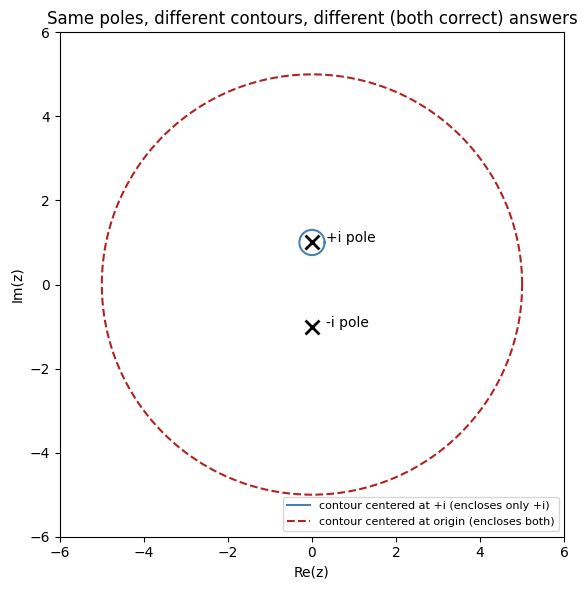

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(0.3*np.cos(theta), 1 + 0.3*np.sin(theta), color='steelblue', label='contour centered at +i (encloses only +i)')
ax.plot(5*np.cos(theta), 5*np.sin(theta), color='firebrick', ls='--', label='contour centered at origin (encloses both)')
ax.plot([0], [1], 'x', color='black', ms=10, mew=2)
ax.plot([0], [-1], 'x', color='black', ms=10, mew=2)
ax.annotate('+i pole', (0, 1), textcoords='offset points', xytext=(10, 0))
ax.annotate('-i pole', (0, -1), textcoords='offset points', xytext=(10, 0))
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
ax.set_title('Same poles, different contours, different (both correct) answers')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('contour_integration_pole_trap.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. A Real Integral via Jordan's Lemma

$\int_{-\infty}^{\infty}\frac{dx}{x^2+a^2}=\frac{\pi}{a}$: close the
contour with a large semicircle in the upper half plane (its contribution
vanishes as the radius grows, since the integrand decays faster than
$1/R$), picking up only the pole at $z=+ia$.


In [4]:
for a in (0.5, 2.0, 5.0):
    r = cir.real_integral_via_residues(a=a)
    print(f"a={a}: direct={r['direct_quadrature']:.6f}, residues={r['residue_theorem_prediction']:.6f}, "
          f"sympy={r['sympy_closed_form']:.6f}, expected pi/a={r['expected_pi_over_a']:.6f}")


a=0.5: direct=6.283185, residues=6.283185, sympy=6.283185, expected pi/a=6.283185
a=2.0: direct=1.570796, residues=1.570796, sympy=1.570796, expected pi/a=1.570796
a=5.0: direct=0.628319, residues=0.628319, sympy=0.628319, expected pi/a=0.628319


## 3. Causality's Fingerprint: Where the Poles Sit

The Lorentz susceptibility $\chi(\omega)=1/(\omega_0^2-\omega^2-i\gamma\omega)$
has two poles. For any physical damping $\gamma>0$, BOTH sit in the lower
half plane ($\mathrm{Im}<0$) -- checked directly, not assumed -- which is
exactly what makes $\chi(z)$ analytic in the upper half plane, the
property the Kramers-Kronig derivation in Section 4 needs.


poles: [ 0.99498744-0.1j -0.99498744-0.1j]
all in lower half plane: True


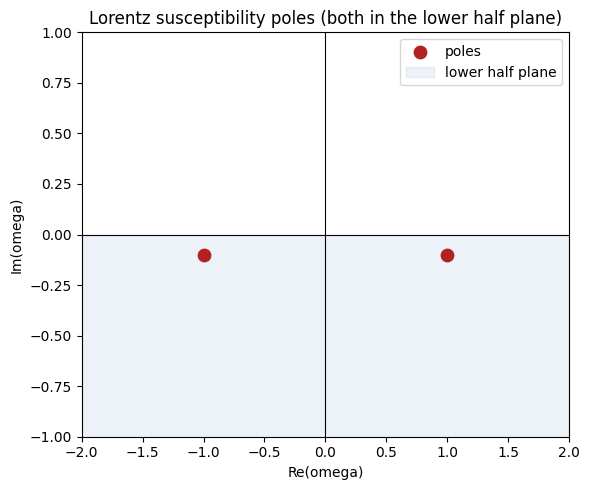

In [5]:
check = cir.verify_poles_in_lower_half_plane(omega0=1.0, gamma=0.2)
print('poles:', check['poles'])
print('all in lower half plane:', check['all_in_lower_half_plane'])

fig, ax = plt.subplots(figsize=(6, 5))
poles = check['poles']
ax.scatter(poles.real, poles.imag, color='firebrick', s=80, zorder=5, label='poles')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.axhspan(-2, 0, alpha=0.1, color='steelblue', label='lower half plane')
ax.set_xlim(-2, 2); ax.set_ylim(-1, 1)
ax.set_xlabel('Re(omega)'); ax.set_ylabel('Im(omega)')
ax.set_title('Lorentz susceptibility poles (both in the lower half plane)')
ax.legend()
plt.tight_layout()
plt.savefig('contour_integration_pole_locations.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Kramers-Kronig, Derived (Not Just Verified)

$$\chi'(\omega_0)=\frac1\pi\,\mathrm{P}\!\!\int\frac{\chi''(\omega)}{\omega-\omega_0}\,d\omega$$

evaluated via SciPy's Cauchy-principal-value quadrature
(`scipy.integrate.quad(..., weight='cauchy')`), compared directly against
the Lorentz susceptibility's own closed-form real part.


In [6]:
for w0 in (0.0, 0.5, 1.5, 2.0):
    kk = cir.kramers_kronig_via_contour_integration(w0)
    print(f"omega0={w0}: KK(contour)={kk['kk_contour_derived_real_part']:.6f}, "
          f"true={kk['true_real_part']:.6f}, diff={kk['abs_diff']:.2e}")


omega0=0.0: KK(contour)=1.000000, true=1.000000, diff=3.40e-10
omega0=0.5: KK(contour)=1.310044, true=1.310044, diff=3.40e-10
omega0=1.5: KK(contour)=-0.756430, true=-0.756430, diff=3.40e-10
omega0=2.0: KK(contour)=-0.327511, true=-0.327511, diff=3.40e-10


## 5. Cross-Check: Contour Integration vs. FFT/Hilbert Transform

Two INDEPENDENT numerical methods -- `dgs.causality`'s FFT-based Hilbert
transform and this module's contour-integration/Cauchy-quadrature
Kramers-Kronig -- on the same discretized Lorentz susceptibility.


max|FFT Hilbert transform - true|:  5.939e-04
max|contour-integration KK - true|: 4.021e-07


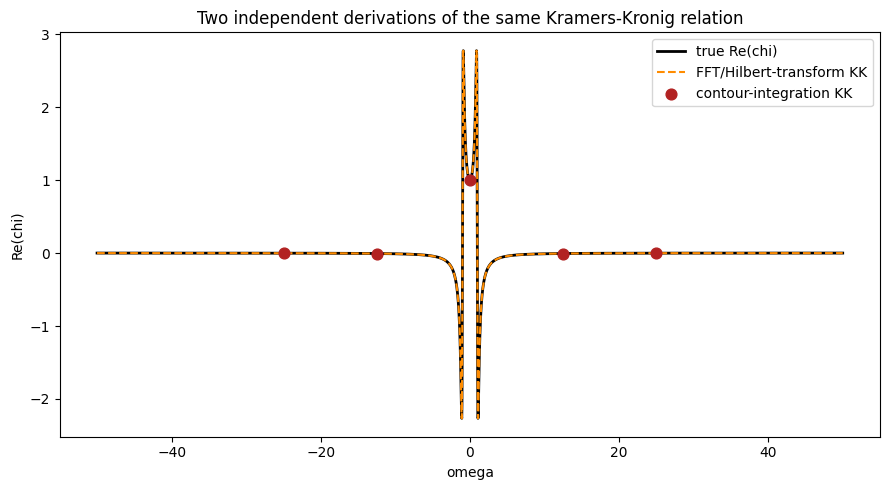

In [7]:
omega_grid = np.linspace(-50, 50, 4000)
cross = cir.cross_check_against_causality_module(omega_grid)
print(f"max|FFT Hilbert transform - true|:  {cross['max_abs_diff_fft_hilbert_vs_true']:.3e}")
print(f"max|contour-integration KK - true|: {cross['max_abs_diff_contour_integration_vs_true']:.3e}")

chi_vals = causality.lorentz_susceptibility(omega_grid, 1.0, 0.2, 1.0)
chi_re_fft = causality.kramers_kronig_real(chi_vals.imag)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(omega_grid, chi_vals.real, color='black', lw=2, label='true Re(chi)')
ax.plot(omega_grid, chi_re_fft, color='darkorange', ls='--', label='FFT/Hilbert-transform KK')
contour_omegas = [r['omega0'] for r in cross['contour_results']]
contour_vals = [r['kk_contour_derived_real_part'] for r in cross['contour_results']]
ax.scatter(contour_omegas, contour_vals, color='firebrick', s=60, zorder=5, label='contour-integration KK')
ax.set_xlabel('omega'); ax.set_ylabel("Re(chi)")
ax.set_title('Two independent derivations of the same Kramers-Kronig relation')
ax.legend()
plt.tight_layout()
plt.savefig('contour_integration_kk_crosscheck.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Engineering Interpretation

- Section 1's pole-enclosure trap is the single most common way to get the
  residue theorem wrong in practice -- both contours in that section give
  CORRECT answers for the contour actually drawn; the "trap" is silently
  assuming a convenient contour encloses the pole you have in mind without
  checking.
- Section 3's pole-location check turns "causality implies analyticity in
  the upper half plane" from a textbook assertion into a directly
  verifiable numeric fact about a specific susceptibility model -- and
  it's the ONE fact the entire Kramers-Kronig derivation in Section 4
  depends on.
- Section 5's cross-check matters because the two methods fail
  differently if either is wrong: an FFT-based Hilbert transform has
  spectral leakage/windowing error, while Cauchy-quadrature has its own
  numerical-integration error near the singularity -- agreement between
  the two is a real cross-validation on two different failure modes, not
  a restatement.


## 7. Research Discussion

- The "iε prescription" from Feynman-propagator physics (shift a
  real-axis pole off the axis by hand to make an otherwise ill-defined
  contour integral well-defined, and to choose retarded vs. advanced
  Green's functions) is the natural next topic this module sets up but
  doesn't cover -- a follow-up module applying it to a driven, undamped
  ($\gamma=0$) oscillator (whose poles sit ON the real axis, unlike this
  module's damped case) would make that connection concrete.
- `dgs.branch_cuts`'s TS-DFT phase-retrieval section and this module's
  Kramers-Kronig derivation are both about the analytic structure of a
  transfer function in the complex frequency plane -- worth an explicit
  side-by-side comparing `H_D(f)=exp(i*pi*D*f^2)` (entire, no poles or
  branch points at all) against the Lorentz susceptibility (poles, no
  branch cut) to catalog which repo transfer functions have which kind of
  complex-plane structure.
- `real_integral_via_residues` only demonstrates Jordan's lemma for a
  simple rational integrand; extending it to an oscillatory integrand
  (e.g. $e^{i\omega t}/(\omega^2+a^2)$, the actual form that appears in
  Green's-function/propagator calculations) would need Jordan's lemma's
  FULL statement (bounding $e^{iz}$ on the arc), not just algebraic decay.


## 8. Possible Experiments

1. Set $\gamma\to 0$ in `lorentz_susceptibility_poles` and watch the
   poles migrate onto the real axis -- confirm the Kramers-Kronig
   contour-integration derivation starts failing (the principal-value
   integral becomes ill-defined) exactly at that limit, connecting to the
   iε-prescription discussion in Section 7.
2. Extend `verify_residue_theorem`'s pole-enclosure trap demo to a
   THIRD contour (e.g. an ellipse, or a non-circular closed curve) and
   confirm the residue theorem doesn't care about the CONTOUR's shape,
   only which poles it encloses.
3. Compute the Kramers-Kronig imaginary-part relation (the OTHER half of
   the pair -- $\chi''$ from $\chi'$) via the same contour-integration
   method, currently only implemented for the real part here.


## 9. Future Improvements

- `kramers_kronig_via_contour_integration` truncates the principal-value
  integral at a finite `integration_limit`; for a susceptibility that
  decays slowly at large $|\omega|$, this truncation error could dominate
  over the Cauchy-quadrature's own numerical error -- worth adding an
  explicit convergence check (increasing the limit until the answer
  stabilizes) rather than a fixed default.
- `cross_check_against_causality_module` only compares 5 query points;
  extending it to compare across the FULL grid (matching
  `dgs.causality.kramers_kronig_real`'s per-point output) would give a
  denser, more thorough cross-validation.
